In [ ]:
import pathlib
import tempfile
import urllib.request

In [ ]:
import marimo as mo
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, ScalarFormatter
import numpy as np
import pandas as pd
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-08-02T15:16:46.670911+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1062-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

marimo    : 0.23.2
numpy     : 2.1.2
teeplot   : 1.4.2
pandas    : 2.2.3
matplotlib: 3.9.2

```

# Exploratory edge sparsity, S1 doubled (2026-07-31): loss vs. n and over time

Downloads the collated timeseries parquet file for the
`2026-07-31-exploratory-edge-sparsity-doubled-s1` SLURM batch job
(see `slurm/2026-07-31/`) from OSF, then renders four single-panel
figures for this dataset's one fixed condition -- L1 on
(`l1_scale=1.0`, `l2_scale=0.0`), the 3-class training set
(`{S1, S2, S3}`), and `--doubled-class 0`, i.e. S1 presented TWICE
as often as S2 or S3 (presentation weights `[0.5, 0.25, 0.25]`, not
uniform `[1/3, 1/3, 1/3]`) -- swept only over `n_zero_edges` in
`[125, 225]` and 10 replicate seeds:

1. Final testing / training (actual) chi^2 error vs. `n_zero_edges`,
   median with a shaded [min, max] band across the 10 seeds.
2. Testing chi^2 error over evolutionary time (generation), one line
   per swept `n_zero_edges` value, colored by a continuous colormap.
3. Training (actual) chi^2 error over evolutionary time, same layout
   as (2) -- `pure_train_chi2` here is scored against the doubled
   `[0.5, 0.25, 0.25]` target (see
   `bindle/2026-07-30-exploratory-edge-sparsity.py`'s
   `--doubled-class`/`train_class_probs`), not a uniform one.
4. Bonus: final S1/S2/S3 phenotype composition vs. `n_zero_edges` --
   directly shows whether the evolved population actually skews
   toward S1 (dotted reference lines at the `0.5`/`0.25` targets),
   which the chi^2 plots alone don't show as directly.

Unlike `bindle/2026-07-31-exploratory-edge-sparsity-analysis.py`
(the base sweep's 4-condition, 2x2-panel analysis notebook), this
dataset has only ONE condition -- `l1_scale`/`l2_scale`/`n_classes`/
`doubled_class` are all fixed by the source SLURM script, only
`n_zero_edges` and `seed` are swept -- so every figure here is a
single panel rather than a 2x2 grid. Every chi^2 y-axis is symlog
(linear below 1.0, log above), matching this project's usual
convention (`CHI2_LINTHRESH = 1.0`).

## Fetch data

In [ ]:
# https://osf.io/4h7wu -- 2026-07-31-exploratory-edge-sparsity-doubled-s1
#   collated timeseries (l1_scale=1.0/l2_scale=0.0, n_classes=3,
#   doubled_class=0 all fixed; n_zero_edges in [125, 225] and seed swept)
OSF_SLUGS = {
    "exploratory-edge-sparsity-doubled-s1": "4h7wu",
}

In [ ]:
def fetch_osf(slug: str) -> "pathlib.Path":
    """Download a file from OSF by its slug, caching it under the system
    temp directory, and return the path to the cached file.

    Tries a plain stdlib download first; if that fails for any reason
    (auth wall, transient network error, redirect handling, ...) falls
    back to the `osf_fetch` utility from this project's `pylib` (ported
    from the same-named utility added to
    github.com/mmore500/paperproject.git), which is more robust
    (session handling via `requests`, on-disk caching)."""
    cache_path = pathlib.Path(tempfile.gettempdir()) / slug
    url = f"https://osf.io/{slug}/download"
    try:
        if not cache_path.exists():
            print(f"downloading {url} -> {cache_path}")
            request = urllib.request.Request(
                url, headers={"User-Agent": "evodd-bindle/1.0"}
            )
            with urllib.request.urlopen(request, timeout=180) as resp:
                cache_path.write_bytes(resp.read())
        else:
            print(f"reusing cached {cache_path}")
    except Exception as e:
        print(
            f"direct download of {url} failed ({e!r}), falling back to pylib.osf_fetch"
        )
        from pylib import osf_fetch

        cache_path = osf_fetch(slug)
    print(f"size: {cache_path.stat().st_size} bytes")
    return cache_path

In [ ]:
osf_paths = {name: fetch_osf(slug) for name, slug in OSF_SLUGS.items()}

downloading https://osf.io/4h7wu/download -> /tmp/4h7wu
direct download of https://osf.io/4h7wu/download failed (<HTTPError 308: 'Permanent Redirect'>), falling back to pylib.osf_fetch
downloading https://osf.io/4h7wu/download -> /tmp/4h7wu
size: 22147580 bytes
size: 22147580 bytes


## Load data

In [ ]:
df = pd.concat(
    [
        pd.read_parquet(path).assign(dataset=name)
        for name, path in osf_paths.items()
    ],
    ignore_index=True,
)
df["dataset"] = pd.Categorical(df["dataset"])

In [ ]:
pd.concat([df.head(), df.tail()])

,epoch,generation,walltime_sec,pure_train_chi2,test_chi2,test1_frac,test2_frac,test3_frac,test4_frac,test5_frac,...,n_zero_edges,n_classes,doubled_class,seed,l1_scale,l2_scale,num_epoch,train_class_idx,replicate_uid,dataset
0,0,0,61.039602,0.998004,0.998008,0.0000,0.0000,0.0000,0.0000,0.0000,...,125,3,0,1,1.0,0.0,138889,"0,3,6",9426f202-3ba2-44fe-b821-2c47f33cb850,exploratory-edge-sparsity-doubled-s1
1,1,138889,61.096207,0.999001,0.999002,0.0000,0.0000,0.0000,0.0000,0.0000,...,125,3,0,1,1.0,0.0,138889,"0,3,6",9426f202-3ba2-44fe-b821-2c47f33cb850,exploratory-edge-sparsity-doubled-s1
2,2,277778,61.198221,0.999001,0.999002,0.0000,0.0000,0.0000,0.0000,0.0000,...,125,3,0,1,1.0,0.0,138889,"0,3,6",9426f202-3ba2-44fe-b821-2c47f33cb850,exploratory-edge-sparsity-doubled-s1
3,3,416667,61.256436,0.998004,0.998008,0.0000,0.0000,0.0000,0.0000,0.0000,...,125,3,0,1,1.0,0.0,138889,"0,3,6",9426f202-3ba2-44fe-b821-2c47f33cb850,exploratory-edge-sparsity-doubled-s1
4,4,555556,61.393289,0.997004,0.997010,0.0005,0.0000,0.0000,0.0000,0.0000,...,125,3,0,1,1.0,0.0,138889,"0,3,6",9426f202-3ba2-44fe-b821-2c47f33cb850,exploratory-edge-sparsity-doubled-s1
176745,170,479583717,4138.562724,0.553905,0.421312,0.1305,0.0130,0.1360,0.0130,0.1270,...,134,3,0,10,1.0,0.0,138889,"0,3,6",d1c9df2b-28e7-44b4-84b1-bfb66b262ff2,exploratory-edge-sparsity-doubled-s1
176746,171,479722606,4138.593068,0.553225,0.420692,0.1300,0.0130,0.1370,0.0135,0.1285,...,134,3,0,10,1.0,0.0,138889,"0,3,6",d1c9df2b-28e7-44b4-84b1-bfb66b262ff2,exploratory-edge-sparsity-doubled-s1
176747,172,489861503,4259.608925,0.552819,0.418332,0.1290,0.0120,0.1350,0.0145,0.1265,...,134,3,0,10,1.0,0.0,138889,"0,3,6",d1c9df2b-28e7-44b4-84b1-bfb66b262ff2,exploratory-edge-sparsity-doubled-s1
176748,173,490000392,4259.639379,0.552551,0.419172,0.1295,0.0120,0.1345,0.0145,0.1265,...,134,3,0,10,1.0,0.0,138889,"0,3,6",d1c9df2b-28e7-44b4-84b1-bfb66b262ff2,exploratory-edge-sparsity-doubled-s1
176749,174,500000400,4303.051702,0.550069,0.422594,0.1315,0.0125,0.1365,0.0135,0.1260,...,134,3,0,10,1.0,0.0,138889,"0,3,6",d1c9df2b-28e7-44b4-84b1-bfb66b262ff2,exploratory-edge-sparsity-doubled-s1


In [ ]:
df.describe()

,epoch,generation,walltime_sec,pure_train_chi2,test_chi2,test1_frac,test2_frac,test3_frac,test4_frac,test5_frac,...,l2_loss,regularization_loss,density,n_zero_edges,n_classes,doubled_class,seed,l1_scale,l2_scale,num_epoch
count,176750.000000,1.767500e+05,176750.000000,176750.000000,176750.000000,176750.000000,176750.000000,176750.000000,176750.000000,176750.000000,...,176750.000000,176750.000000,176750.000000,176750.000000,176750.0,176750.0,176750.000000,176750.0,176750.0,176750.0
mean,87.000000,1.711343e+08,1605.722614,0.723040,1.152477,0.195034,0.007951,0.011788,0.015965,0.013385,...,0.094819,0.018972,0.316406,175.000000,3.0,0.0,5.500000,1.0,0.0,138889.0
std,50.517467,1.568387e+08,1485.773461,0.185362,0.789688,0.201024,0.022492,0.036696,0.044480,0.036276,...,0.075692,0.009178,0.113886,29.154842,0.0,0.0,2.872289,0.0,0.0,0.0
min,0.000000,0.000000e+00,61.023999,0.214822,0.009800,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.121094,125.000000,3.0,0.0,1.000000,1.0,0.0,138889.0
25%,43.000000,2.041668e+07,184.783111,0.560901,0.809176,0.051000,0.000000,0.000000,0.000000,0.000000,...,0.017743,0.012408,0.218750,150.000000,3.0,0.0,3.000000,1.0,0.0,138889.0
50%,87.000000,1.313890e+08,1219.730617,0.721353,0.916483,0.125500,0.000000,0.000000,0.000000,0.000000,...,0.112953,0.024856,0.316406,175.000000,3.0,0.0,5.500000,1.0,0.0,138889.0
75%,131.000000,3.029169e+08,2744.109002,0.873113,1.000000,0.262500,0.001000,0.001000,0.002500,0.000500,...,0.145764,0.025031,0.414062,200.000000,3.0,0.0,8.000000,1.0,0.0,138889.0
max,174.000000,5.000004e+08,8307.524079,1.000000,5.391060,0.879500,0.214500,0.785500,0.405500,0.203500,...,0.907491,0.035401,0.511719,225.000000,3.0,0.0,10.000000,1.0,0.0,138889.0


## Verify the fixed condition

This dataset sweeps only `n_zero_edges` and `seed` -- everything
else (`l1_scale`, `l2_scale`, `n_classes`, `doubled_class`) should be
a single fixed value throughout, matching
`slurm/2026-07-31/2026-07-31-exploratory-edge-sparsity-doubled-s1.sh`.

In [ ]:
assert df["l1_scale"].nunique() == 1 and df["l1_scale"].iloc[0] == 1.0
assert df["l2_scale"].nunique() == 1 and df["l2_scale"].iloc[0] == 0.0
assert df["n_classes"].nunique() == 1 and df["n_classes"].iloc[0] == 3
assert (
    df["doubled_class"].nunique() == 1 and df["doubled_class"].iloc[0] == 0
)
n_zero_values = sorted(df["n_zero_edges"].unique())

In [ ]:
condition_summary_df = pd.DataFrame(
    [
        {
            "l1_scale": df["l1_scale"].iloc[0],
            "l2_scale": df["l2_scale"].iloc[0],
            "n_classes": df["n_classes"].iloc[0],
            "doubled_class": df["doubled_class"].iloc[0],
            "n_zero_edges_min": min(n_zero_values),
            "n_zero_edges_max": max(n_zero_values),
            "n_zero_edges_count": len(n_zero_values),
            "n_seeds": df["seed"].nunique(),
        }
    ]
)
condition_summary_df

,l1_scale,l2_scale,n_classes,doubled_class,n_zero_edges_min,n_zero_edges_max,n_zero_edges_count,n_seeds
0,1.0,0.0,3,0,125,225,101,10


## Plot 1: final test/train loss vs. n_zero_edges

In [ ]:
def _use_readable_symlog_ticks(axis):
    # matplotlib's default symlog locator/formatter collapses to a
    # single offset-notation label (instead of normal tick labels)
    # whenever the visible range never actually crosses linthresh --
    # MaxNLocator + ScalarFormatter reads fine in that case *and*
    # when the range does cross into the log region.
    axis.set_major_locator(MaxNLocator(nbins=6))
    axis.set_major_formatter(ScalarFormatter())

def make_final_loss_plot(df, n_zero_values):
    CHI2_LINTHRESH = 1.0

    # each replicate's own last recorded row -- not a single shared
    # max generation across the whole sweep -- since replicates can
    # be truncated at different generations by a SLURM timeout (see
    # bindle/2026-07-30-exploratory-edge-sparsity.py's progressive
    # save-out). In practice every replicate in this dataset reaches
    # the full 500,000,400-generation budget, but this stays robust
    # regardless.
    final = (
        df.sort_values("generation")
        .groupby(["n_zero_edges", "seed"], observed=True)
        .tail(1)
    )
    agg = (
        final.groupby("n_zero_edges", observed=True)[
            ["pure_train_chi2", "test_chi2"]
        ]
        .agg(["median", "min", "max"])
        .reindex(n_zero_values)
    )

    fig, ax = plt.subplots(figsize=(8, 5.5), dpi=90)
    # line_color deliberately contrasts with (rather than matches)
    # its own band_color -- complementary-ish hues, not just the
    # same color at different alpha -- so the median line stays
    # legible against a wide min-max band instead of blending into
    # it (see bindle/2026-07-31-exploratory-edge-sparsity-analysis.py).
    for metric_col, line_color, band_color, ls, label in (
        ("test_chi2", "#e6550d", "#1f77b4", "-", "testing"),
        (
            "pure_train_chi2",
            "#238b45",
            "#d62728",
            "--",
            "training (actual, vs. doubled target)",
        ),
    ):
        ax.fill_between(
            n_zero_values,
            agg[(metric_col, "min")],
            agg[(metric_col, "max")],
            color=band_color,
            alpha=0.2,
            lw=0,
        )
        ax.plot(
            n_zero_values,
            agg[(metric_col, "median")],
            color=line_color,
            ls=ls,
            lw=1.8,
            label=label,
        )
    ax.set_yscale("symlog", linthresh=CHI2_LINTHRESH)
    ax.set_ylim(bottom=0)
    _use_readable_symlog_ticks(ax.yaxis)
    ax.set_xlim(min(n_zero_values), max(n_zero_values))
    ax.set_xlabel("n_zero_edges (of 256 possible)")
    ax.set_ylabel("chi$^2$ error")
    ax.set_title(
        "doubled-S1: final testing / training chi$^2$ error vs. "
        "n_zero_edges"
    )
    ax.legend(loc="upper left", fontsize=9, frameon=False)
    fig.tight_layout()
    return fig

teeplots/2026-07-31-exploratory-edge-sparsity-doubled-s1-analysis/dataset=exploratory-edge-sparsity-doubled-s1+viz=make-final-loss-plot+ext=.pdf
teeplots/2026-07-31-exploratory-edge-sparsity-doubled-s1-analysis/dataset=exploratory-edge-sparsity-doubled-s1+viz=make-final-loss-plot+ext=.png



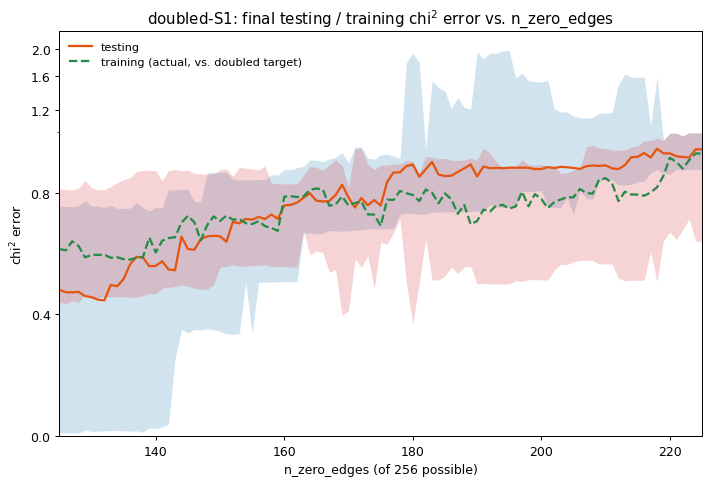

In [ ]:
with tp.teed(
    make_final_loss_plot,
    df,
    n_zero_values,
    teeplot_outattrs={"dataset": "exploratory-edge-sparsity-doubled-s1"},
    teeplot_subdir=pathlib.Path(__file__).stem,
    teeplot_show=False,
) as _fig:
    pass
mo.output.append(_fig)
plt.close(_fig)

## Plots 2 & 3: loss over evolutionary time, colored by n_zero_edges

One median line per swept `n_zero_edges` value (101 lines) against
generation (log-scaled, starting at 10^6), colored by a continuous
colormap (`n_zero_edges` -> viridis, shown via colorbar) rather than
a discrete per-line legend -- with 101 distinct swept values, a
discrete legend isn't practical. No min/max band is shown here (101
overlapping bands would be unreadable); see plot 1 above for
replicate spread at each n. Y-axis is symlog (linear below chi^2=1,
log above).

In [ ]:
def _use_readable_symlog_ticks(axis):
    axis.set_major_locator(MaxNLocator(nbins=6))
    axis.set_major_formatter(ScalarFormatter())

def make_over_time_plot(df, metric_col, metric_label):
    GEN_LOG_FLOOR = 1e6
    CHI2_LINTHRESH = 1.0
    df = df[df["generation"] >= GEN_LOG_FLOOR]

    n_min = df["n_zero_edges"].min()
    n_max = df["n_zero_edges"].max()
    norm = Normalize(vmin=n_min, vmax=n_max)
    cmap = plt.get_cmap("viridis")

    agg = (
        df.groupby(["n_zero_edges", "generation"], observed=True)[
            metric_col
        ]
        .median()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(8, 5.5), dpi=90)
    for n_val, g in agg.groupby("n_zero_edges", observed=True):
        g = g.sort_values("generation")
        ax.plot(
            g["generation"],
            g[metric_col],
            color=cmap(norm(n_val)),
            lw=0.8,
            alpha=0.85,
        )
    ax.set_xscale("log")
    ax.set_xlim(left=GEN_LOG_FLOOR)
    ax.set_yscale("symlog", linthresh=CHI2_LINTHRESH)
    ax.set_ylim(bottom=0)
    _use_readable_symlog_ticks(ax.yaxis)
    ax.set_xlabel("generation")
    ax.set_ylabel("chi$^2$ error")
    ax.set_title(
        f"doubled-S1: {metric_label} chi$^2$ error over evolutionary "
        "time"
    )
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("n_zero_edges (of 256 possible)")
    fig.tight_layout()
    return fig

teeplots/2026-07-31-exploratory-edge-sparsity-doubled-s1-analysis/dataset=exploratory-edge-sparsity-doubled-s1+metric=test+viz=make-over-time-plot+ext=.pdf
teeplots/2026-07-31-exploratory-edge-sparsity-doubled-s1-analysis/dataset=exploratory-edge-sparsity-doubled-s1+metric=test+viz=make-over-time-plot+ext=.png



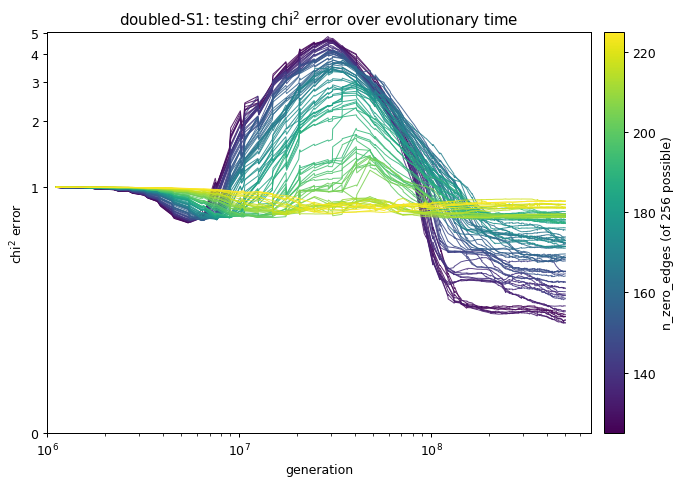

In [ ]:
with tp.teed(
    make_over_time_plot,
    df,
    "test_chi2",
    "testing",
    teeplot_outattrs={
        "dataset": "exploratory-edge-sparsity-doubled-s1",
        "metric": "test",
    },
    teeplot_subdir=pathlib.Path(__file__).stem,
    teeplot_show=False,
) as _fig:
    pass
mo.output.append(_fig)
plt.close(_fig)

teeplots/2026-07-31-exploratory-edge-sparsity-doubled-s1-analysis/dataset=exploratory-edge-sparsity-doubled-s1+metric=train+viz=make-over-time-plot+ext=.pdf
teeplots/2026-07-31-exploratory-edge-sparsity-doubled-s1-analysis/dataset=exploratory-edge-sparsity-doubled-s1+metric=train+viz=make-over-time-plot+ext=.png



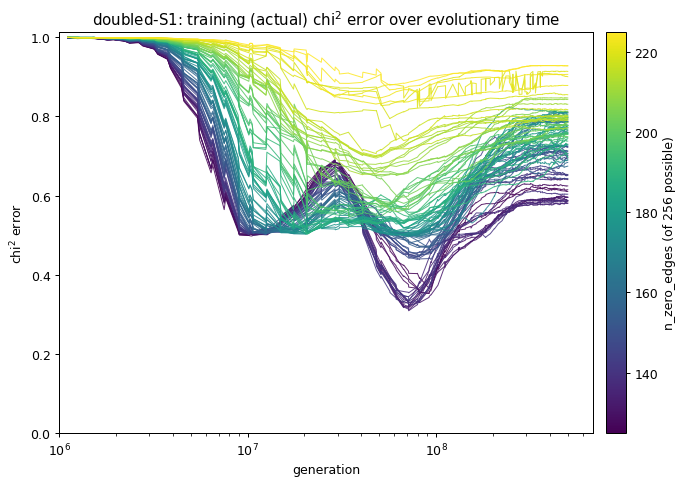

In [ ]:
with tp.teed(
    make_over_time_plot,
    df,
    "pure_train_chi2",
    "training (actual)",
    teeplot_outattrs={
        "dataset": "exploratory-edge-sparsity-doubled-s1",
        "metric": "train",
    },
    teeplot_subdir=pathlib.Path(__file__).stem,
    teeplot_show=False,
) as _fig:
    pass
mo.output.append(_fig)
plt.close(_fig)

## Plot 4 (bonus): final S1/S2/S3 phenotype composition vs. n_zero_edges

The chi^2 plots above measure how far the evolved population is from
the doubled `[0.5, 0.25, 0.25]` target, but not which direction --
this plot shows the actual median final `test1_frac`/`test4_frac`/
`test7_frac` (S1/S2/S3, `CLASS_8` indices 0/3/6) directly, with
dotted reference lines at the `0.5`/`0.25` presentation-weight
targets, so it's immediately visible whether S1 actually pulls ahead
of S2/S3 as intended.

In [ ]:
def make_composition_plot(df, n_zero_values):
    final = (
        df.sort_values("generation")
        .groupby(["n_zero_edges", "seed"], observed=True)
        .tail(1)
    )
    comp_cols = ["test1_frac", "test4_frac", "test7_frac"]
    agg = (
        final.groupby("n_zero_edges", observed=True)[comp_cols]
        .median()
        .reindex(n_zero_values)
    )

    fig, ax = plt.subplots(figsize=(8, 5.5), dpi=90)
    for col, label, color in (
        ("test1_frac", "S1 (doubled)", "#e6194B"),
        ("test4_frac", "S2", "#3cb44b"),
        ("test7_frac", "S3", "#4363d8"),
    ):
        ax.plot(n_zero_values, agg[col], color=color, lw=1.8, label=label)
    ax.axhline(0.5, color="#e6194B", ls=":", lw=1, alpha=0.6)
    ax.axhline(0.25, color="gray", ls=":", lw=1, alpha=0.6)
    ax.set_xlim(min(n_zero_values), max(n_zero_values))
    ax.set_ylim(0, 1)
    ax.set_xlabel("n_zero_edges (of 256 possible)")
    ax.set_ylabel("final phenotype fraction")
    ax.set_title(
        "doubled-S1: final S1/S2/S3 phenotype composition vs. "
        "n_zero_edges"
    )
    ax.legend(loc="upper right", fontsize=9, frameon=False)
    fig.tight_layout()
    return fig

teeplots/2026-07-31-exploratory-edge-sparsity-doubled-s1-analysis/dataset=exploratory-edge-sparsity-doubled-s1+viz=make-composition-plot+ext=.pdf
teeplots/2026-07-31-exploratory-edge-sparsity-doubled-s1-analysis/dataset=exploratory-edge-sparsity-doubled-s1+viz=make-composition-plot+ext=.png



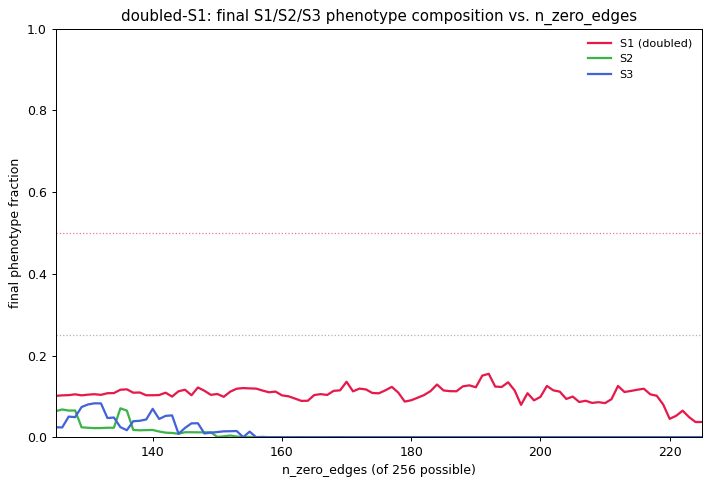

In [ ]:
with tp.teed(
    make_composition_plot,
    df,
    n_zero_values,
    teeplot_outattrs={"dataset": "exploratory-edge-sparsity-doubled-s1"},
    teeplot_subdir=pathlib.Path(__file__).stem,
    teeplot_show=False,
) as _fig:
    pass
mo.output.append(_fig)
plt.close(_fig)